In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PINN(nn.Module):

    def __init__(self,layers):

        super().__init__()

        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()

        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i],layers[i+1]))

    def forward(self,x):

        for i in range(len(self.layers)-1):
            x = self.activation(self.layers[i](x))

        x = self.layers[-1](x)

        return x

layers = [2,64,64,64,1]
model = PINN(layers)

In [3]:
def sample_interior(n):

    x = -1 + 2*torch.rand(n,1)
    t = torch.rand(n,1)

    pts = torch.cat([x,t],1)

    pts.requires_grad = True

    return pts

Initial Condition at t = 0


In [4]:
def sample_initial(n):

    x = -1 + 2*torch.rand(n,1)
    t = torch.zeros_like(x)

    pts = torch.cat([x,t],1)

    u = -torch.sin(np.pi*x)

    return pts,u

Boundary at At x = -1 and x = 1.

In [5]:
def sample_boundary(n):

    t = torch.rand(n,1)

    left = torch.cat([-torch.ones_like(t),t],1)
    right = torch.cat([torch.ones_like(t),t],1)

    pts = torch.cat([left,right],0)

    u = torch.zeros(2*n,1)

    return pts,u

In [6]:
nu = 0.01/np.pi

def pde_residual(model,pts):

    u = model(pts)

    grads = torch.autograd.grad(
        u,pts,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = grads[:,0:1]
    u_t = grads[:,1:2]

    u_xx = torch.autograd.grad(
        u_x,pts,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:,0:1]

    residual = u_t + u*u_x - nu*u_xx

    return residual

In [9]:
def physics_loss(model,pts):

    r = pde_residual(model,pts)

    return torch.mean(r**2)

def initial_loss(model,pts,u):

    pred = model(pts)

    return torch.mean((pred-u)**2)

def boundary_loss(model,pts,u):

    pred = model(pts)

    return torch.mean((pred-u)**2)

In [10]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

epochs = 10000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    interior = sample_interior(2000)

    ic_pts,ic_u = sample_initial(200)

    bc_pts,bc_u = sample_boundary(200)

    p_loss = physics_loss(model,interior)

    i_loss = initial_loss(model,ic_pts,ic_u)

    b_loss = boundary_loss(model,bc_pts,bc_u)

    loss = p_loss + i_loss + b_loss

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch%500==0:
        print(epoch,loss.item())

0 0.5190809369087219
500 0.11599396169185638
1000 0.09577372670173645
1500 0.08289256691932678
2000 0.04919961094856262
2500 0.04317669942975044
3000 0.03559701889753342
3500 0.03060377761721611
4000 0.023501981049776077
4500 0.017147844657301903
5000 0.017410367727279663
5500 0.011914670467376709
6000 0.011002486571669579
6500 0.01039278507232666
7000 0.0149339959025383
7500 0.0070867761969566345
8000 0.006226340774446726
8500 0.00480580935254693
9000 0.004349994007498026
9500 0.004088647663593292


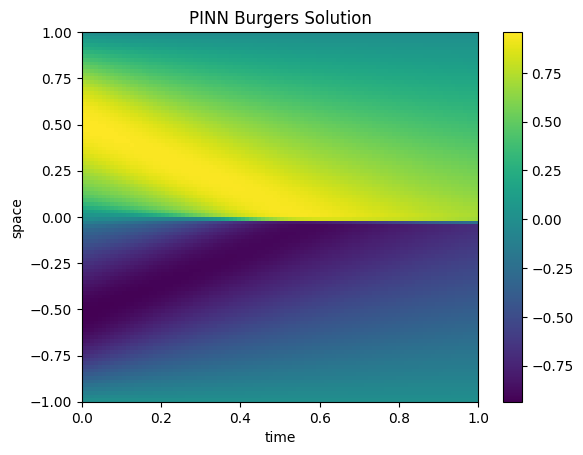

In [11]:
x = torch.linspace(-1,1,100)
t = torch.linspace(0,1,100)

X,T = torch.meshgrid(x,t,indexing="ij")

pts = torch.stack([X.flatten(),T.flatten()],1)

with torch.no_grad():

    pred = model(pts)

pred = pred.reshape(100,100)

plt.imshow(pred,extent=[0,1,-1,1],aspect='auto')
plt.xlabel("time")
plt.ylabel("space")
plt.title("PINN Burgers Solution")
plt.colorbar()
plt.show()



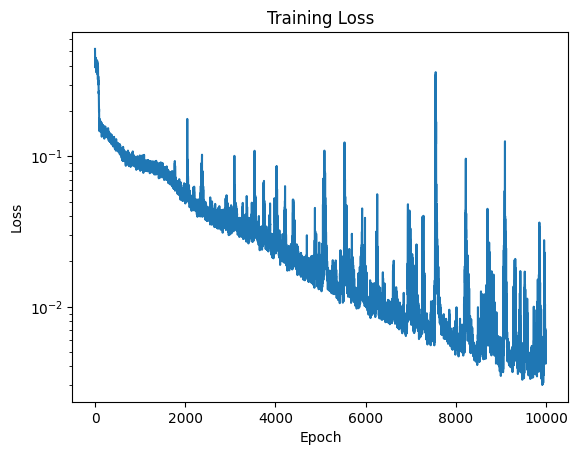

In [12]:
plt.figure()
plt.plot(loss_history)
plt.yscale("log")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()